# PyTorch Workflow

Let's explore an example PyTorch end-to-end workflow.

![alt text](source/pytorch-workflow.png)

Resources:

* Ground truth notebook - 
https://github.com/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb

* Book version of notebook - 
https://www.learnpytorch.io/01_pytorch_workflow/

In [1]:
what_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to data (training)",
                      4:"making predictions and evaluating a model (inference)",
                      5:"saving and loading a model",
                      6:"putting it all together"}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

![alt text](source/sieci-neuronowe-grafika-1024x759.png)

In [2]:
import torch
from torch import nn # nn contains all the building blocks for neural networks.
import matplotlib.pyplot as plt

# Check PyTorch version
print(torch.__version__)

2.10.0+cu128


## 1. Data (preparing and loading)

Data can be almost anything... in machine learning.

* Excel spreadsheet
* Images of any kind
* Videos (Youtube has lots of data...)
* Audio like songs or podcasts
* DNA
* Text
![alt text](source/data.png)
Machine learning is a game of two parts:
1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.

To showcase this, let's create some *known* data using the linear regression formula.

We'll use a linear regression formula to make a straight line with known **parameters**.


In [3]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
x = torch.arange(start, end, step).unsqueeze(dim=1) 
y = weight * x + bias

x[:10], y[:10], len(x), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [4]:
len(x), len(y) 

(50, 50)

### Splitting data into training and test sets (one of the most important concepts in machine learning in general)

Each split of the dataset serves a specific purpose:

| Split          | Purpose                                                                                                                      | Amount of total data | How often is it used? |
|----------------|------------------------------------------------------------------------------------------------------------------------------|----------------------|-----------------------|
| Training set   | The model learns from this data (like the course materials you study during the semester).                                   | ~60–80%              | Always                |
| Validation set | The model gets tuned on this data (like the practice exam you take before the final exam).                                   | ~10–20%              | Often but not always  |
| Testing set    | The model gets evaluated on this data to test what it has learned (like the final exam you take at the end of the semester). | ~10–20%              | Always                |

In [5]:
# Create a training and test split
train_split = int(0.8 * len(x))
x_train, y_train = x[:train_split], y[:train_split] # 80% of the data for training
x_test, y_test = x[train_split:], y[train_split:] # 20% of the data for testing

len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?

This is where the data explorer's motto comes in!

"Visualize, Visualize, Visualize!"

In [6]:
def plot_predictions(train_data=x_train,
                    train_labels=y_train,
                    test_data=x_test,
                    test_labels=y_test,
                    predictions=None):
        """
        Plots training data, test data and compares predictions.
        """

        plt.figure(figsize=(10, 7))

        # Plot training data in blue
        plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

        # Plot test data in green
        plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
       
        # Are there predictions?
        if predictions is not None:
           # Plot the predictions if they exist
           plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

        # Show the legend
        plt.legend(prop={"size":14})

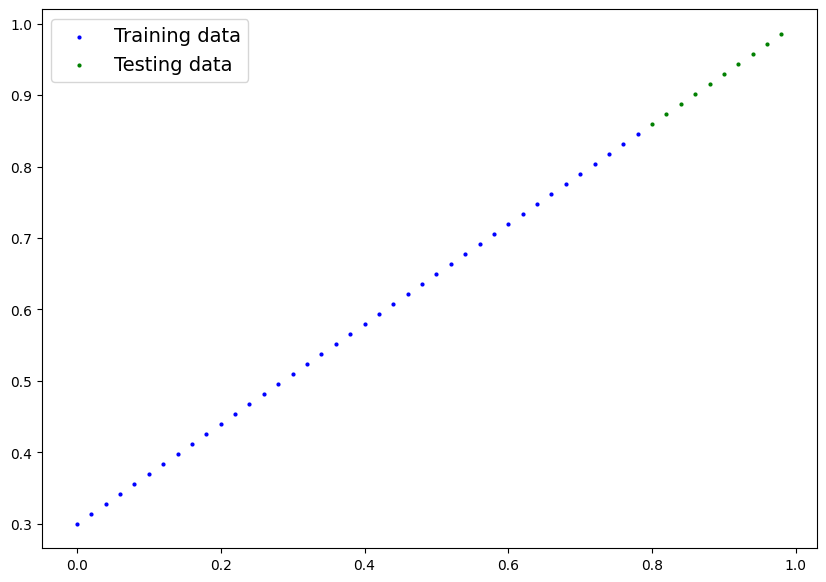

In [7]:
plot_predictions()

## 2. Build a model

Our first PyTorch model!

This is very exciting..let's do it!

Because we're going to be building classes throughout the course,I'd recommend getting familiar with OOP in Python, to do so you can use the following resource from Real Python: 

https://realpython.com/

What our model does:
* Start with random values (weight & bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

Through two main algorithms:
* Gradient descent: https://www.youtube.com/watch?v=IHZwWFHWa-w
* Backpropagation: https://www.youtube.com/watch?v=Ilg3gGewQ5U


![alt text](source/01-pytorch-linear-model-annotated.png)

In [8]:
from torch import nn

# Create a linear regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.rand(1,   # <- start with a random weight and try to adjust it to the ideal weight
                                               requires_grad=True, # <- can this be changed during training? (required for training)
                                               dtype = torch.float)) # <- PyTorch loves the datatype torch.float32
        
        self.bias = nn.Parameter(torch.rand(1, # <- start with a random bias and try to adjust it to the ideal bias
                                            requires_grad=True, # <- can this be changed during training? (required for training)
                                            dtype = torch.float)) # <- PyTorch loves the datatype torch.float32

    # Forward method to define the commutation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data
        return self.weights * x + self.bias # this is the linear regression formula


### PyTorch model building essentials

| Component            | Description                                                                                                                |
| -------------------- | -------------------------------------------------------------------------------------------------------------------------- |
| `torch.nn`           | Contains all the building blocks for computational graphs (a neural network can be viewed as a computational graph).       |
| `torch.nn.Parameter` | Represents the parameters that the model should learn; often automatically defined within layers in `torch.nn`.            |
| `torch.nn.Module`    | The base class for all neural network modules; when subclassing it, you must override the `forward()` method.              |
| `torch.optim`        | Provides optimization algorithms (e.g., SGD, Adam) used to perform gradient descent and update model parameters.           |
| `def forward()`          | A method that must be implemented in every `nn.Module` subclass; defines the forward pass (computation flow) of the model. |

See: https://pytorch-cn.com/tutorials/beginner/ptcheat.html
 

### Checking the contents of our PyTorch model

Now we've created a model, let's see what's inside..

So we can check our model parameters or what's inside our model using `parameters()`.

In [9]:
# Create a random seed 
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [10]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

## Making prediction using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `x_test`.

When we pass data through our model, it's going to run it through the forward() method.

In [11]:
x_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [12]:
# Make predictions with the untrained model
with torch.inference_mode(): # <- turns off gradients (we don't need them for inference)
    y_preds = model_0(x_test)

# You can also do something similar with torch.no_grad(), however, inference_mode() is preferred.
# with torch.no_grad():
#     y_preds = model_0(x_test)

**Note:** In older PyTorch code, you may also see `torch.no_grad()` being used for inference. While `torch.inference_mode()` and `torch.no_grad()` do similar things, `torch.inference_mode()` is newer, potentially faster and preferred. See this [Tweet from PyTorch](https://x.com/PyTorch/status/1437838231505096708?s=20) for more.

In [13]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

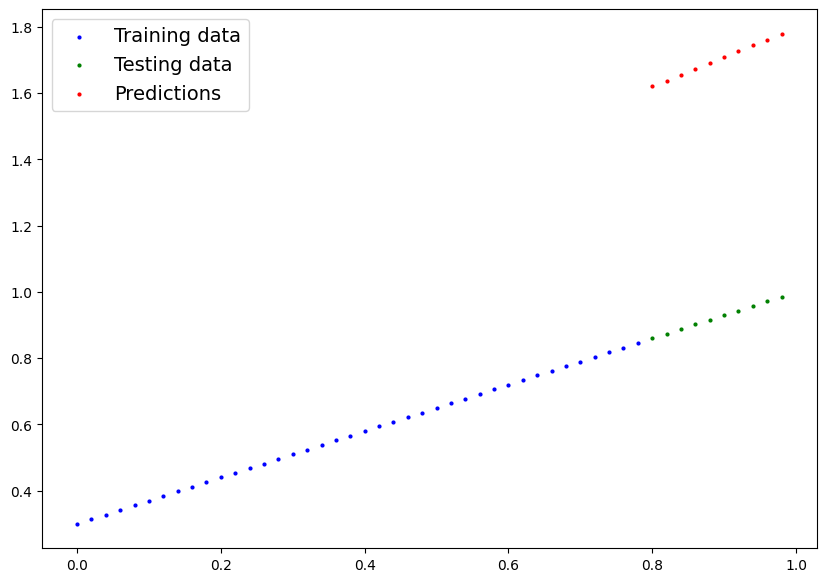

In [14]:
plot_predictions(predictions=y_preds)

## 3. Train model

The whole idea of training is for a model to move from some unknown parameters(these may be random) to some known parameters.

Or in other words from a poor representation of the data to a better representation of the data.

One way to measure how poor or how wrong your models predictions are is to use a loss function.

* Note: Loss function may also be called cost function or criterion in different areas. For our case, we're going to refer to it as a loss function.

Things we need to train:

**Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.

**Optimizer:** Takes into account the loss of a model and adjust the model's parameters (e.g. weight & bias) to improve the loss function.

And specifically for PyTorch, we need:
* A training loop
* A testing loop

In [15]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [16]:
# Check out our model's parameters (a parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [17]:
# Setup a loss function
loss_fn = nn.L1Loss() # <- also called mean absolute error (MAE)

# Setup an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr = 0.01) # lr = learning rate = possibly the most important hyperparameter you can set 

### Building a train loop in PyTorch

A couple of things we need in a training loop:
1. Loop through the data.
2. Forward pass (this involves data moving through our model's `forward()` functions) to make predictions on data - also called forward propagation.
3. Calculate the loss (compare forward pass predictions to ground truth labels).
4. Optimizer zero grad.
5. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss(**backpropagation**).
6. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss(**gradient descent**)

![alt text](source/01-pytorch-training-loop-annotated.png)

![alt text](source/01-pytorch-testing-loop-annotated.png)

In [18]:
print(list(model_0.parameters()))

[Parameter containing:
tensor([0.8823], requires_grad=True), Parameter containing:
tensor([0.9150], requires_grad=True)]


In [19]:
torch.manual_seed(42)

# An epoch is one loop through the data...
# (this is a hyperparameter because we've set it ourselves)
epochs = 201

# Track different values to see how they're changing
epoch_count = []
loss_values = []
test_loss_values = []

# 0. Loop through data
for epoch in range(epochs):
    # put the model in training mode.
    model_0.train()  # train mode in PyTorch set all parameters to require gradients (which is required for training)

    # 1. Forward pass
    y_pred = model_0(x_train)

    # 2. Calculate the loss
    train_loss = loss_fn(y_pred, y_train)
    # print(f"Epoch: {epoch} | Loss: {loss:.4f}")

    # 3. Optimize the zero gradients
    optimizer.zero_grad() # <- zero the gradients (by default, gradients are accumulated in PyTorch)

    # 4.Perform backpropagation on the loss with respect to the parameters of the model
    train_loss.backward() # <- calculate the gradients of the loss with respect to the parameters of the model

    # 5. Step the optimizer (perform gradient descent)
    optimizer.step() # <- by default how the optimizer changes will accumulate through the loop.. we have to zero them above in step 3 for the next iteration of the loop

    ### Testing
    model_0.eval() # turn off different settings in the model not needed for evaluation/testing
    with torch.inference_mode(): # turns off gradient tracking && a couple more things behind the scenes which we don't need for inference/testing/evaluation
    # with torch.no_grad(): # you can also use this but inference_mode() is preferred
        
        # 1. Do the forward pass
        test_pred = model_0(x_test)

        # 2. Calculate the loss 
        test_loss = loss_fn(test_pred, y_test) 

    # Print out what happened
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(train_loss.item()) # .item() gets the Python number from a tensor containing a single value
        test_loss_values.append(test_loss.item())
        print(f"Epoch: {epoch} | Loss: {train_loss:.4f} | Test loss: {test_loss:.4f}")
        # Print out model state_dict()
        print(model_0.state_dict())

Epoch: 0 | Loss: 0.6861 | Test loss: 0.7638
OrderedDict({'weights': tensor([0.8784]), 'bias': tensor([0.9050])})
Epoch: 10 | Loss: 0.5709 | Test loss: 0.6290
OrderedDict({'weights': tensor([0.8394]), 'bias': tensor([0.8050])})
Epoch: 20 | Loss: 0.4557 | Test loss: 0.4943
OrderedDict({'weights': tensor([0.8004]), 'bias': tensor([0.7050])})
Epoch: 30 | Loss: 0.3405 | Test loss: 0.3596
OrderedDict({'weights': tensor([0.7614]), 'bias': tensor([0.6050])})
Epoch: 40 | Loss: 0.2252 | Test loss: 0.2249
OrderedDict({'weights': tensor([0.7224]), 'bias': tensor([0.5050])})
Epoch: 50 | Loss: 0.1100 | Test loss: 0.0902
OrderedDict({'weights': tensor([0.6834]), 'bias': tensor([0.4050])})
Epoch: 60 | Loss: 0.0097 | Test loss: 0.0210
OrderedDict({'weights': tensor([0.6539]), 'bias': tensor([0.3200])})
Epoch: 70 | Loss: 0.0062 | Test loss: 0.0141
OrderedDict({'weights': tensor([0.6707]), 'bias': tensor([0.3120])})
Epoch: 80 | Loss: 0.0028 | Test loss: 0.0058
OrderedDict({'weights': tensor([0.6878]), 'b

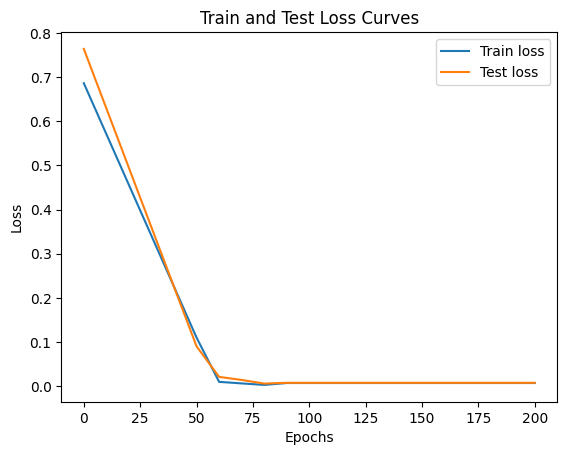

In [20]:
import numpy as np
# Plot the loss curves
plt.plot(epoch_count, loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Train and Test Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 4. Making predictions with a trained PyTorch model (inference)
Once you've trained a model, you'll likely want to make predictions with it.

We've already seen a glimpse of this in the training and testing code above, the steps to do it outside of the training/testing loop are similar.

There are three things to remember when making predictions (also called performing inference) with a PyTorch model:

1. Set the model in evaluation mode (model.eval()).
2. Make the predictions using the inference mode context manager (with torch.inference_mode(): ...).
3. All predictions should be made with objects on the same device (e.g. data and model on GPU only or data and model on CPU only).
   
The first two items make sure all helpful calculations and settings PyTorch uses behind the scenes during training but aren't necessary for inference are turned off (this results in faster computation). And the third ensures that you won't run into cross-device errors.

In [21]:
with torch.inference_mode():
    y_preds_new = model_0(x_test)

model_0.state_dict()

OrderedDict([('weights', tensor([0.6938])), ('bias', tensor([0.2980]))])

In [22]:
weight, bias

(0.7, 0.3)

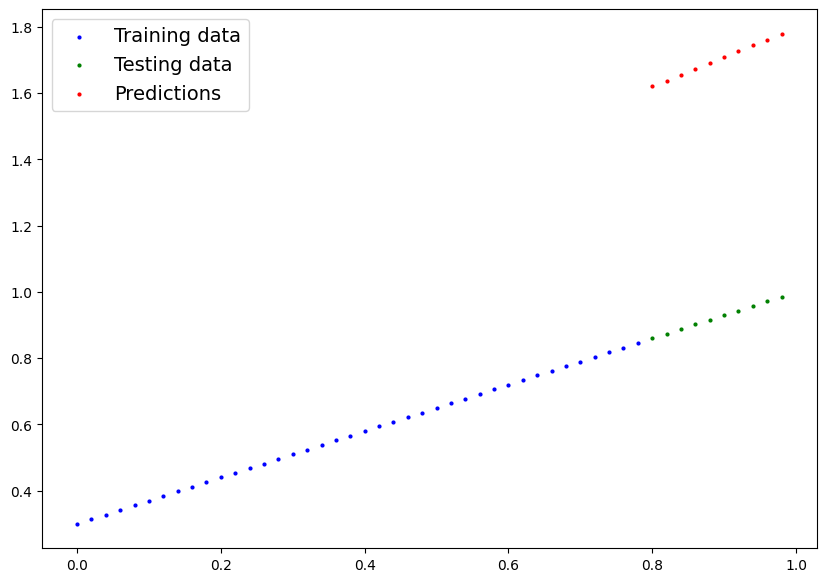

In [23]:
plot_predictions(predictions=y_preds)

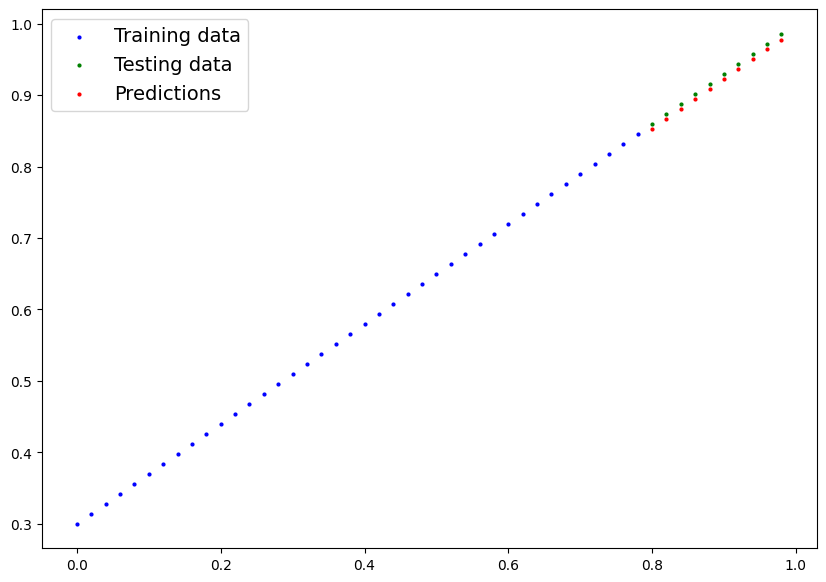

In [24]:
plot_predictions(predictions=y_preds_new)

## 5. Saving and loading a PyTorch model

If you've trained a PyTorch model, chances are you'll want to save it and export it somewhere.

As in, you might train it on Google Colab or your local machine with a GPU but you'd like to now export it to some sort of application where others can use it.

Or maybe you'd like to save your progress on a model and come back and load it back later.

### Saving a model in PyTorch

There are three main methods you should about for saving and loading models in PyTorch.

1. `torch.save()` - allows you save a PyTorch object in Python's pickle format.
2. `torch.load()` - allows you load a saved PyTorch object.
3. `torch.nn.Module.load_state_dict()` - this allows to load a model's saved state dictionary.

**note:**  Pytorch save & load code tutorial + extra-curriculum - See https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html

Note: It's common convention for PyTorch saved models or objects to end with `.pt` or `.pth`, like `saved_model_01.pth`.

In [25]:
from pathlib import Path

# 1. Create a directory for saving models
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create a model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_FILE = MODEL_PATH / MODEL_NAME

# 3. Save the model state_dict()
torch.save(obj=model_0.state_dict(), f=MODEL_FILE)
print(f"Model saved to: {MODEL_FILE}")

Model saved to: models/01_pytorch_workflow_model_1.pth


### Loading a PyTorch model

Since we saved our model's `state_dict()` rather the entire model, we'll create a new instance of our model class and `state_dict` into that.

In [26]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6938])), ('bias', tensor([0.2980]))])

In [27]:
# Load the model from Google Drive

# To load a model, you need to have an instance of the model class first
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict() of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f = MODEL_FILE))

<All keys matched successfully>

In [28]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6938])), ('bias', tensor([0.2980]))])

In [29]:
# Make some predictions with the loaded model
loaded_model_0.eval() # set the model to evaluation mode

with torch.inference_mode():
    loaded_model_preds = loaded_model_0(x_test)

loaded_model_preds

tensor([[0.8530],
        [0.8669],
        [0.8808],
        [0.8946],
        [0.9085],
        [0.9224],
        [0.9363],
        [0.9501],
        [0.9640],
        [0.9779]])

In [30]:
# Compare loaded model predictions with original model predictions
y_preds == loaded_model_preds

tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])

In [31]:
# Make some models preds
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(x_test)

y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. Putting it all together

Let's go back through the steps above and see it all in one place.

In [32]:
# Check PyTorch version
print(torch.__version__)

2.10.0+cu128


Create device-agnostic code.

This means if we've got access to a GPU, our code will use it(for potentially faster computing).

If no GPU is available, the code will default to using CPU.

In [33]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### 6.1 Data

In [34]:
import torch
import matplotlib.pyplot as plt

# Create some data using the linear regression formula (y = weight * x + bias) with some noise
weight = 0.7
bias = 0.3

# Create a range of values
start = 0
end = 1
step = 0.02

# Create x and y
x = torch.arange(start, end, step).unsqueeze(dim=1) # without unsqueeze, x would be a 1D tensor, we want it to be a 2D tensor (n_samples, n_features) for our model
y = weight * x + bias
x[:10], y[:10], len(x), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [35]:
# Split the data into training and test sets
train_split = int(0.8 * len(x))
x_train, y_train = x[:train_split], y[:train_split] # 80% of the data for training
x_test, y_test = x[train_split:], y[train_split:] # 20% of the data for testing
len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

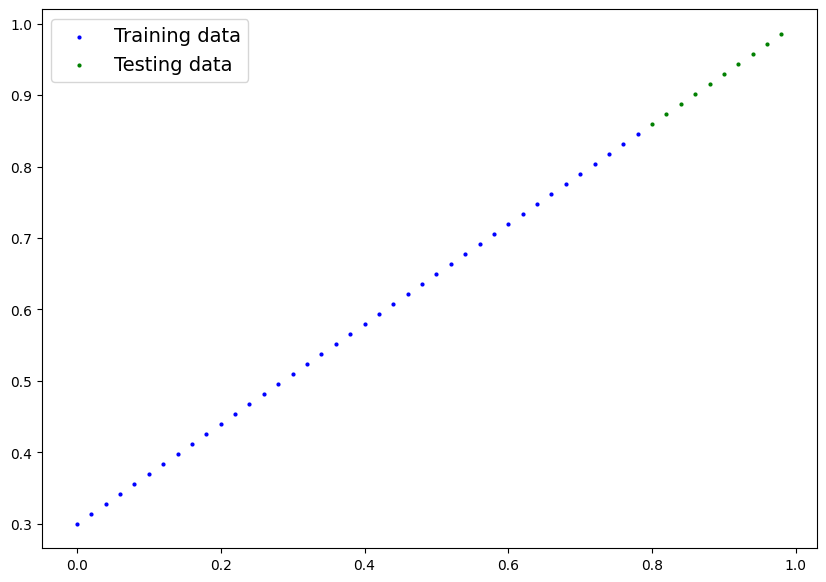

In [36]:
# Plot the data
# Note: if you don't have the plot_predictions() function, this will error.
plot_predictions(x_train, y_train, x_test, y_test)

### 6.2 Building a PyTorch Linear model

**Note:** See https://docs.pytorch.org/docs/stable/nn.html later.

![alt text](source/01-pytorch-linear-regression-model-with-nn-Parameter-and-nn-Linear-compared.png)

In [37]:
# Create a linear model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() to create the model parameters (this is a linear layer)
        self.linear_layer = nn.Linear(in_features=1, # <- one feature in, this is because our x data has one feature (the value of x)
                                      out_features=1) # <- one output feature, this is because our y data has
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [38]:
# Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2() # <- create an instance of the model and move it to the device (GPU or CPU)
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [39]:
x_train[:5], y_train[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

In [40]:
# Check the model current device
next(model_1.parameters()).device

device(type='cpu')

In [41]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.3 Training 
For training we need:
* Loss function
* Optimizer
* Training loop
* Testing loop

In [42]:
# Set up the loss function
loss_fn = nn.L1Loss() # <- also called mean absolute error (MAE)

# Set up the optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01) # lr = learning rate = possibly the most important hyperparameter you can set

In [43]:
# Let's write a training loop for 200 epochs
torch.manual_seed(42)
epochs = 201

# Put the data on the same device as the model
x_train = x_train.to(device)
y_train = y_train.to(device)
x_test = x_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    model_1.train() # set the model to training mode

    # 1. Forward pass
    y_pred = model_1(x_train) # make sure to move the data to the same device as the model

    # 2. Calculate the loss
    train_loss = loss_fn(y_pred, y_train) # make sure to move the data to the same device as the model

    # 3. Optimize the zero gradients
    optimizer.zero_grad()

    # 4. Perform backpropagation on the loss with respect to the parameters of the model
    train_loss.backward()

    # 5. Step the optimizer (perform gradient descent)
    optimizer.step()

    ### Testing
    model_1.eval() # set the model to evaluation mode
    with torch.inference_mode(): # turns off gradient tracking
        # 1. Do the forward pass
        test_pred = model_1(x_test) # make sure to move the data to the same device as the model

        # 2. Calculate the loss 
        test_loss = loss_fn(test_pred, y_test) # make sure to move the data to the same device as the model

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} |  Train Loss: {train_loss:.4f} |  Test Loss: {test_loss:.4f}")

Epoch: 0 |  Train Loss: 0.5552 |  Test Loss: 0.5740
Epoch: 10 |  Train Loss: 0.4400 |  Test Loss: 0.4393
Epoch: 20 |  Train Loss: 0.3248 |  Test Loss: 0.3046
Epoch: 30 |  Train Loss: 0.2095 |  Test Loss: 0.1698
Epoch: 40 |  Train Loss: 0.0943 |  Test Loss: 0.0351
Epoch: 50 |  Train Loss: 0.0239 |  Test Loss: 0.0478
Epoch: 60 |  Train Loss: 0.0200 |  Test Loss: 0.0458
Epoch: 70 |  Train Loss: 0.0165 |  Test Loss: 0.0375
Epoch: 80 |  Train Loss: 0.0131 |  Test Loss: 0.0299
Epoch: 90 |  Train Loss: 0.0097 |  Test Loss: 0.0217
Epoch: 100 |  Train Loss: 0.0062 |  Test Loss: 0.0141
Epoch: 110 |  Train Loss: 0.0028 |  Test Loss: 0.0058
Epoch: 120 |  Train Loss: 0.0013 |  Test Loss: 0.0138
Epoch: 130 |  Train Loss: 0.0013 |  Test Loss: 0.0138
Epoch: 140 |  Train Loss: 0.0013 |  Test Loss: 0.0138
Epoch: 150 |  Train Loss: 0.0013 |  Test Loss: 0.0138
Epoch: 160 |  Train Loss: 0.0013 |  Test Loss: 0.0138
Epoch: 170 |  Train Loss: 0.0013 |  Test Loss: 0.0138
Epoch: 180 |  Train Loss: 0.0013 |  Tes

In [44]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6929]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.2925], device='cuda:0'))])

### 6.4 Making and evaluating predictions

In [45]:
# Turn the model into evaluation mode
model_1.eval()

# Make predictions with the trained model
with torch.inference_mode():
    y_preds = model_1(x_test)
y_preds

tensor([[0.8468],
        [0.8607],
        [0.8746],
        [0.8884],
        [0.9023],
        [0.9161],
        [0.9300],
        [0.9438],
        [0.9577],
        [0.9716]], device='cuda:0')

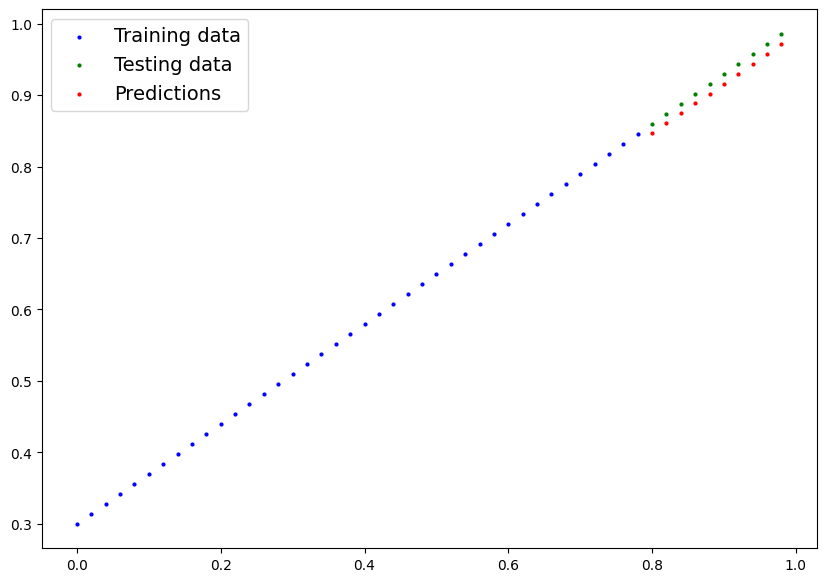

In [46]:
# Check out our model's predictions
plot_predictions(predictions=y_preds.cpu()) # move the predictions back to the CPU for plotting

### 6.5 Saving & Loading a trained model

In [47]:
import torch
from pathlib import Path
from google.colab import drive
 
# 1. Mount Google Drive (this will prompt you to authorize access)
drive.mount('/content/drive')
 
# 2. Define the save path in Google Drive
# It's recommended to create a dedicated folder for PyTorch in MyDrive to keep things organized.
GRIVE_MODEL_PATH = Path("/content/drive/MyDrive/pytorch_models")
GRIVE_MODEL_PATH.mkdir(parents=True, exist_ok=True) # Create the directory if it doesn't exist

# 3. Set the model name and final save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = GRIVE_MODEL_PATH / MODEL_NAME

# 4. Save the model to Google Drive
print(f"Saving model to Google Drive: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)

print("✅You can find it in the 'pytorch_models' folder on Google Drive.")

Mounted at /content/drive
Saving model to Google Drive: /content/drive/MyDrive/pytorch_models/01_pytorch_workflow_model_1.pth
✅You can find it in the 'pytorch_models' folder on Google Drive.


In [48]:
# Load the model from Google Drive

# To load a model, you need to have an instance of the model class first
loaded_model_1 = LinearRegressionModelV2()

# Load the saved state_dict() of model_0 (this will update the new instance with updated parameters)
loaded_model_1.load_state_dict(torch.load(f = MODEL_SAVE_PATH))

# Put the loaded model on the same device as the original model
loaded_model_1.to(device)

# Check the loaded model's state_dict()
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6929]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.2925], device='cuda:0'))])

In [49]:
import os

GOOGLE_DRIVE_PATH = Path("/content/drive/MyDrive/pytorch_models")
GOOGLE_DRIVE_PATH.mkdir(parents=True, exist_ok=True)

# List all .pth files in the Google Drive folder
model_files = list(GOOGLE_DRIVE_PATH.glob("*.pth"))

if len(model_files) > 0:
    for i, file in enumerate(model_files, 1):
        # Get the file size in bytes and convert to megabytes
        file_size = os.path.getsize(file) / (1024 * 1024)
        print(f"{i}. file name: {file.name} | size: {file_size:.2f} MB")
    print("-" * 30)
else:
    print("❌ Warning: No .pth files found in the folder.")

1. file name: 01_pytorch_workflow_model_0.pth | size: 0.00 MB
2. file name: 01_pytorch_workflow_model_1.pth | size: 0.00 MB
------------------------------


In [50]:
# Evaluate the loaded model
loaded_model_1.eval() # set the model to evaluation mode
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(x_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')

## Exercises & Extra-curriculum

refer to: https://www.learnpytorch.io/01_pytorch_workflow/#extra-curriculum